# 03 — Feature Engineering
Bounteous Motors AI — Vehicle Price Prediction

This notebook takes the cleaned dataset produced in `02_DataCleaning.ipynb` and applies the
feature-engineering steps defined in `feature_engineering.py`, then explores the new features
before they're handed to the model-training pipeline in `04_ModelTraining.ipynb`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_dataset
from cleaning import clean_dataset
from feature_engineering import engineer_features

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

## Load and clean the raw dataset
Reusing `data_loader.load_dataset()` and `cleaning.clean_dataset()` so this notebook stays in sync with the production pipeline.

In [4]:
df = load_dataset()
df = clean_dataset(df)
df.shape

NameError: name 'load_dataset' is not defined

In [ ]:
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R Lxi Cng,Mumbai,2010,72000,Cng,Manual,First,26.60,998.0,58.16,5.0,227.5
1,Hyundai Creta 1.6 Crdi Sx Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,1625.0
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,585.0
3,Maruti Ertiga Vdi,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,780.0
4,Audi A4 New 2.0 Tdi Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,2306.2


## Columns before feature engineering

In [4]:
df.columns.tolist()

['Name',
 'Location',
 'Year',
 'Kilometers_Driven',
 'Fuel_Type',
 'Transmission',
 'Owner_Type',
 'Mileage',
 'Engine',
 'Power',
 'Seats',
 'Price']

## Apply feature engineering
`engineer_features()` extracts `Brand` and `Model` from the free-text `Name` field, computes
`Car_Age`, `Kilometers_Per_Year`, `Power_Per_CC`, and flags `Luxury_Brand`.

In [5]:
df_fe = engineer_features(df.copy())
df_fe.head()

Starting feature engineering...
✓ Brand extracted.
✓ Model extracted.
✓ Car_Age created.
✓ Luxury_Brand created.
✓ Kilometers_Per_Year created.
✓ Power_Per_CC created.
✓ Name column dropped.
Feature engineering complete.


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model,Car_Age,Luxury_Brand,Kilometers_Per_Year,Power_Per_CC
0,Mumbai,2010,72000,Cng,Manual,First,26.60,998.0,58.16,5.0,227.5,Maruti,Wagon R Lxi Cng,16,0,4500.000000,0.058277
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,1625.0,Hyundai,Creta 1.6 Crdi Sx Option,11,0,3727.272727,0.079772
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,585.0,Honda,Jazz V,15,0,3066.666667,0.073978
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,780.0,Maruti,Ertiga Vdi,14,0,6214.285714,0.071122
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,2306.2,Audi,A4 New 2.0 Tdi Multitronic,13,1,3128.461538,0.071545


In [6]:
print("Columns added:", sorted(set(df_fe.columns) - set(df.columns) | {"Brand", "Model"}))
print("Columns removed:", sorted(set(df.columns) - set(df_fe.columns)))
df_fe.shape

Columns added: ['Brand', 'Car_Age', 'Kilometers_Per_Year', 'Luxury_Brand', 'Model', 'Power_Per_CC']
Columns removed: ['Name']


(6019, 17)

## Brand and Model extraction
A quick check that the text-splitting logic in `extract_brand` / `extract_model` behaves sensibly.

In [7]:
df_fe[['Brand', 'Model']].head(10)

,Brand,Model
0,Maruti,Wagon R Lxi Cng
1,Hyundai,Creta 1.6 Crdi Sx Option
2,Honda,Jazz V
3,Maruti,Ertiga Vdi
4,Audi,A4 New 2.0 Tdi Multitronic
5,Hyundai,Eon Lpg Era Plus Option
6,Nissan,Micra Diesel Xv
7,Toyota,Innova Crysta 2.8 Gx At 8S
8,Volkswagen,Vento Diesel Comfortline
9,Tata,Indica Vista Quadrajet Ls


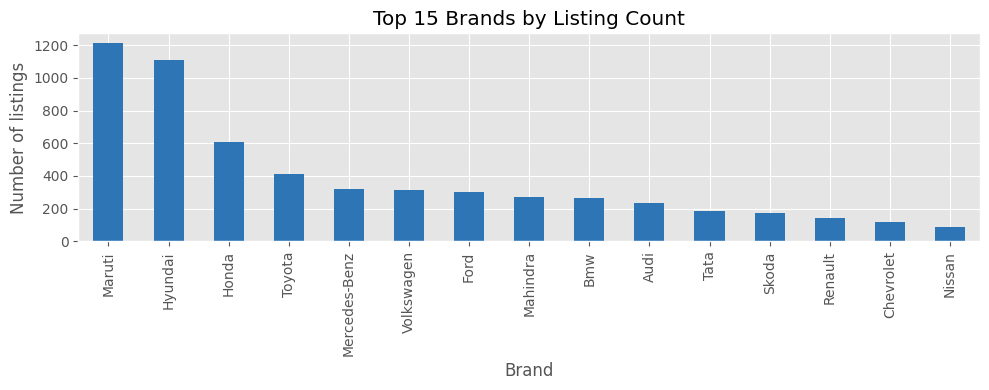

In [8]:
df_fe['Brand'].value_counts().head(15).plot(kind='bar', figsize=(10, 4), color='#2E75B6')
plt.title('Top 15 Brands by Listing Count')
plt.ylabel('Number of listings')
plt.tight_layout()
plt.show()

## Luxury_Brand flag
A binary flag marking cars from the predefined luxury brand set (Audi, BMW, Jaguar, Lexus, Mercedes-Benz, Volvo, Porsche, Land [Rover]).

In [9]:
df_fe['Luxury_Brand'].value_counts()

Luxury_Brand
0    5326
1     693
Name: count, dtype: int64

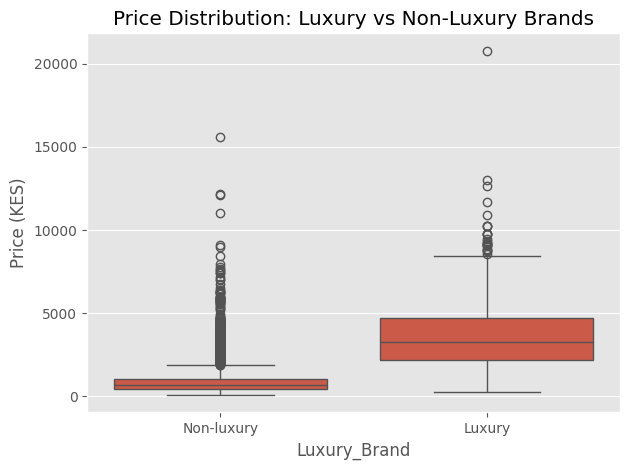

In [10]:
sns.boxplot(data=df_fe, x='Luxury_Brand', y='Price')
plt.xticks([0, 1], ['Non-luxury', 'Luxury'])
plt.title('Price Distribution: Luxury vs Non-Luxury Brands')
plt.ylabel('Price (KES)')
plt.tight_layout()
plt.show()

## Car_Age and Kilometers_Per_Year
Derived from `Year` and `Kilometers_Driven` — these tend to carry more predictive signal than the raw columns alone.

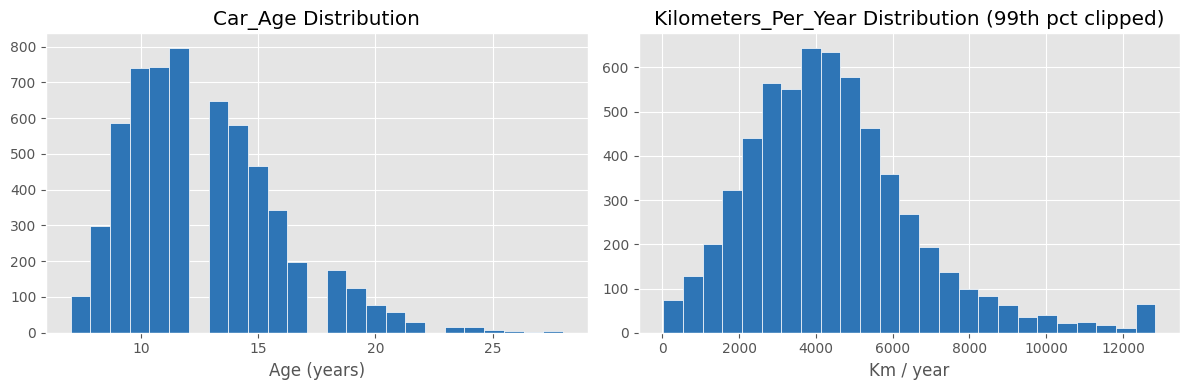

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_fe['Car_Age'], bins=25, color='#2E75B6', edgecolor='white')
axes[0].set_title('Car_Age Distribution')
axes[0].set_xlabel('Age (years)')

axes[1].hist(df_fe['Kilometers_Per_Year'].clip(upper=df_fe['Kilometers_Per_Year'].quantile(0.99)), bins=25, color='#2E75B6', edgecolor='white')
axes[1].set_title('Kilometers_Per_Year Distribution (99th pct clipped)')
axes[1].set_xlabel('Km / year')

plt.tight_layout()
plt.show()

## Power_Per_CC
Engine power relative to displacement — a proxy for how highly tuned/performance-oriented the engine is.

In [12]:
df_fe['Power_Per_CC'].describe()

count    6019.000000
mean        0.068900
std         0.014552
min         0.023842
25%         0.061635
50%         0.067174
75%         0.075674
max         0.569444
Name: Power_Per_CC, dtype: float64

## Correlation of engineered numeric features with Price

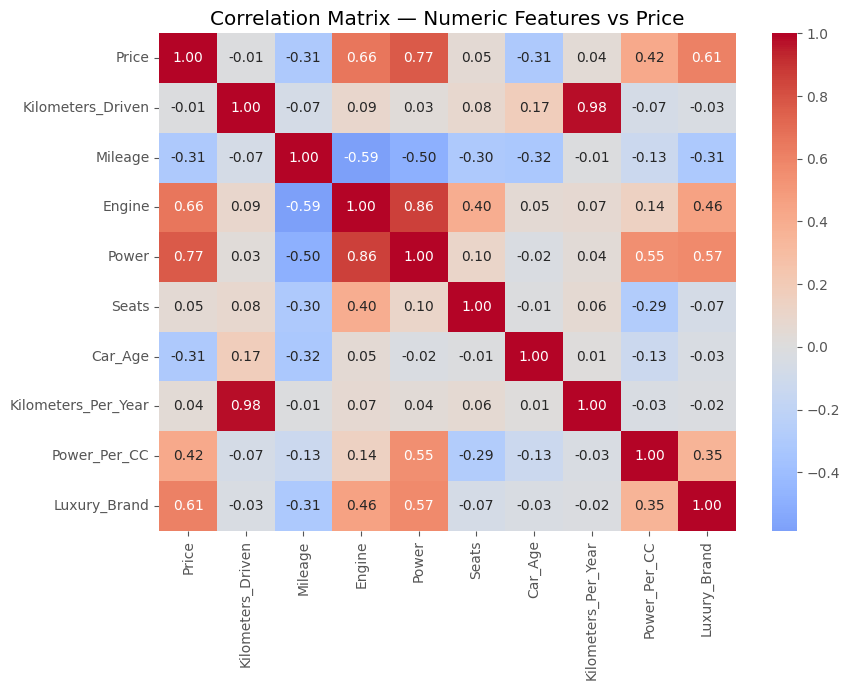

In [13]:
numeric_cols = ['Price', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats',
                 'Car_Age', 'Kilometers_Per_Year', 'Power_Per_CC', 'Luxury_Brand']

corr = df_fe[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numeric Features vs Price')
plt.tight_layout()
plt.show()

In [14]:
corr['Price'].sort_values(ascending=False)

Price                  1.000000
Power                  0.769711
Engine                 0.657347
Luxury_Brand           0.609950
Power_Per_CC           0.420339
Seats                  0.053787
Kilometers_Per_Year    0.041900
Kilometers_Driven     -0.011493
Car_Age               -0.305327
Mileage               -0.306588
Name: Price, dtype: float64

## Takeaways
- `Power_Per_CC`, `Car_Age`, and `Luxury_Brand` all show a meaningful correlation with `Price`,
  confirming they're worth including alongside the raw columns.
- `Car_Age` is unsurprisingly negatively correlated with price (older cars are cheaper) and is
  effectively a cleaner re-expression of `Year`.
- These engineered columns, plus the untouched categorical fields, feed directly into the
  preprocessing pipeline (`preprocessing.py`) used in `04_ModelTraining.ipynb`.